In [26]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [27]:
vivi = np.array(Image.open('vivi.jpg'))
(l,c,p) = vivi.shape
pesos = np.array([0.2126, 0.7152, 0.0722])
vivi_gray = (vivi[..., :3] * pesos).sum(axis=2).astype(np.uint8)

In [28]:
def histogram_gray(img):
    (l, c,) = img.shape
    # Histograma com 1 linha e 256 colunas, preenchido com 0.
    histogram = np.zeros(256, dtype=np.int32)

    for i in range(l):
        for j in range(c):
            # Normalizar intensidade do pixel 
            intensity = img[i, j]
            # Incrementar de 1 a quantidade de pixels no histograma,
            # utilizando a intensidade como índice.
            histogram[intensity] += 1
            
    return histogram

def show_histogram_gray(img):
    histogram = histogram_gray(img)
    plt.figure(figsize=(16, 16))
    plt.subplot(2, 1, 1)
    # vmin e vmax não permitem que o matplotlib faça normalização das cores.
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.subplot(2, 1, 2)
    plt.bar(range(256), histogram)

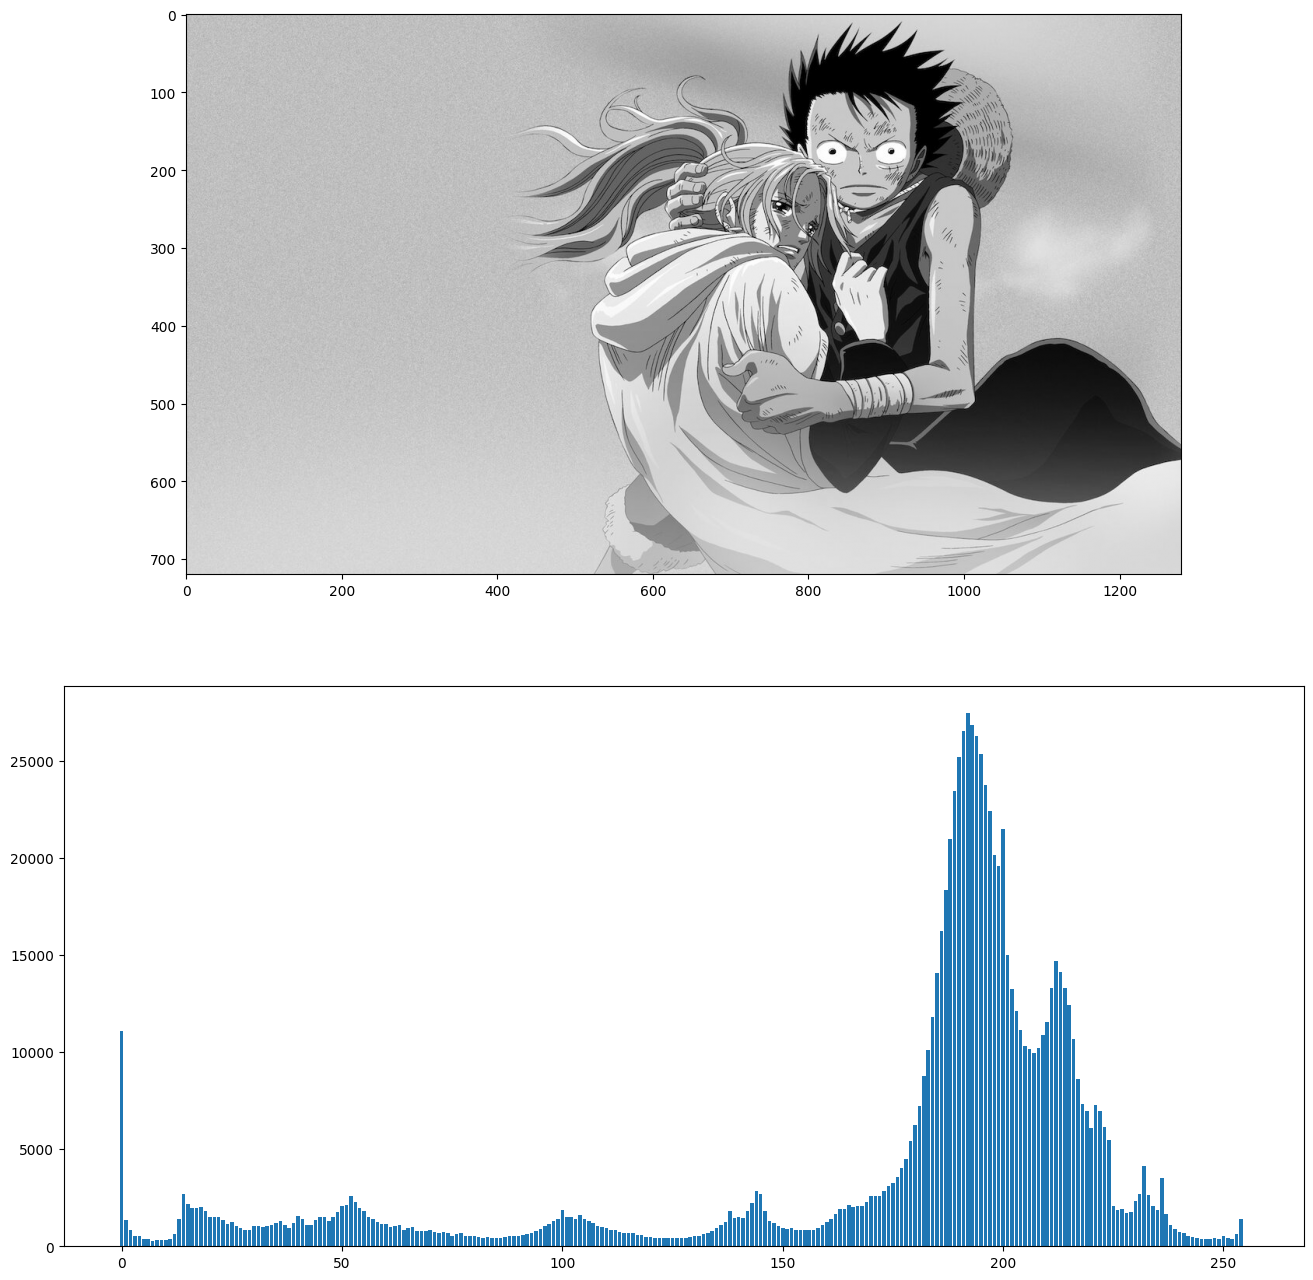

In [29]:
show_histogram_gray(vivi_gray)

## Histograma de Cores RGB

In [30]:
def show_histogram(img):
    # Usando o Ellipsis para pegar todas as dimensões espaciais e o canal específico
    histogram_r = histogram_gray(vivi[..., 0])
    histogram_g = histogram_gray(vivi[..., 1])
    histogram_b = histogram_gray(vivi[..., 2])

    plt.figure(figsize=(16, 16))
    plt.subplot(2, 1, 2)
    plt.imshow(vivi_gray, cmap='gray', vmin=0, vmax=255)
    plt.subplot(2, 1, 1)
    plt.bar(range(256), histogram_r, color='red')
    plt.bar(range(256), histogram_g, color='green')
    plt.bar(range(256), histogram_b, color='blue')

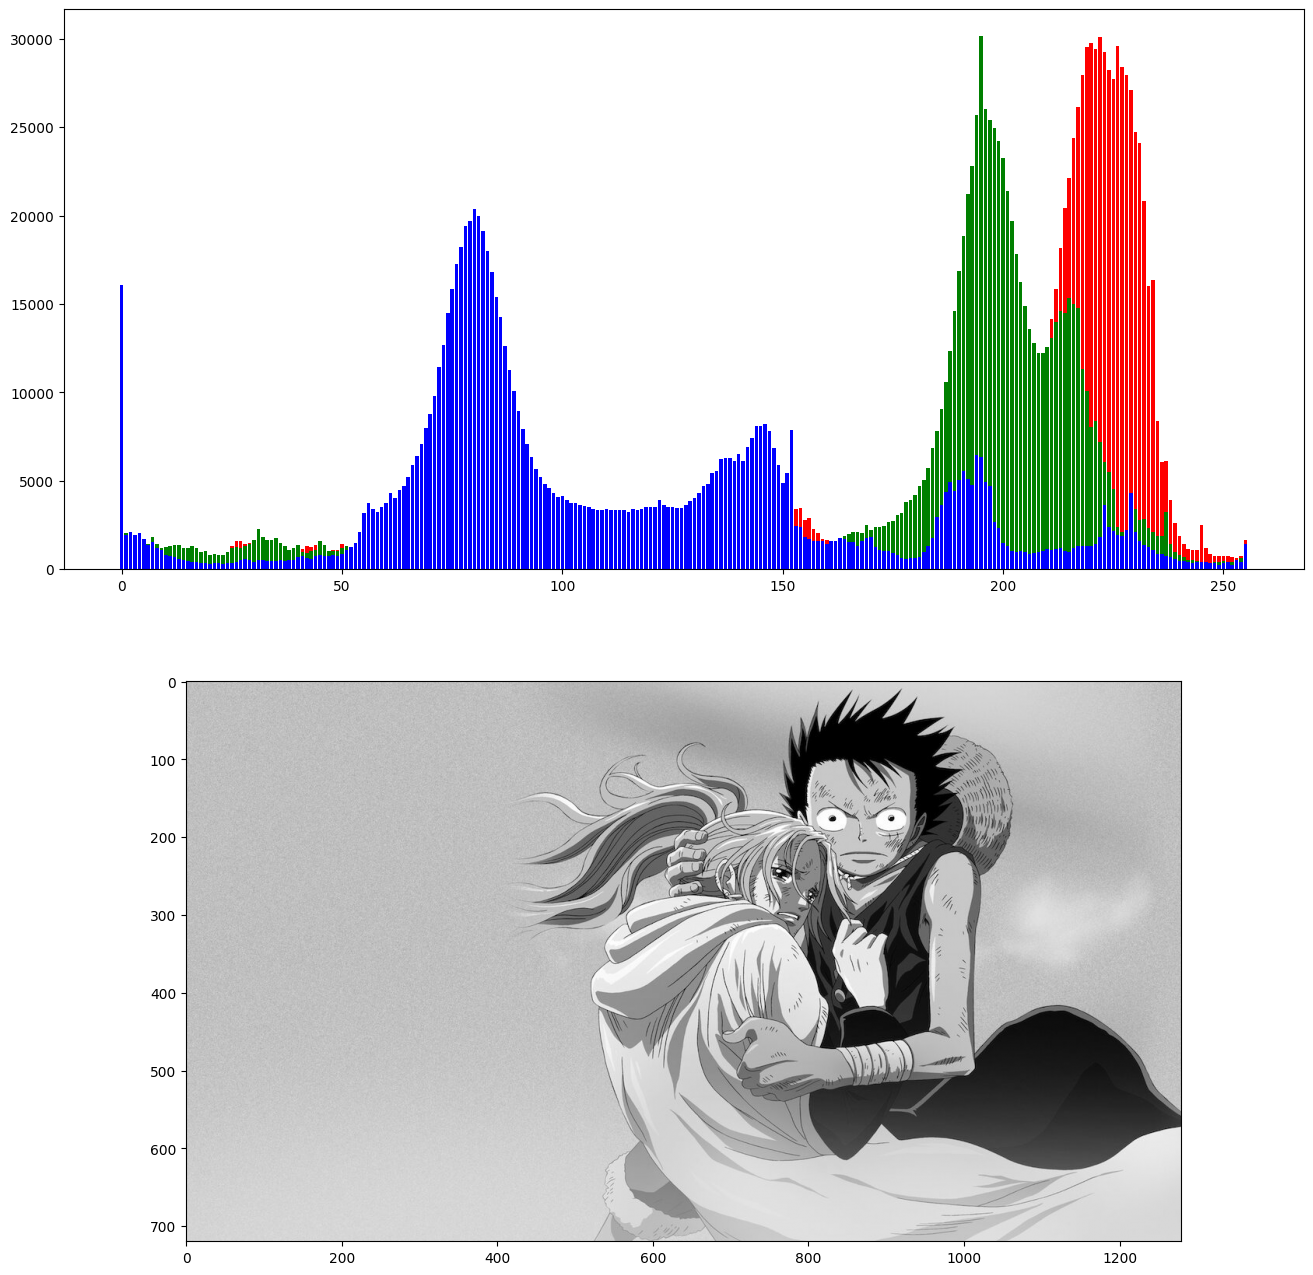

In [31]:
show_histogram(vivi_gray)

## Equalização

- Funciona com base em FDC (Função Densidade Cumulativa)

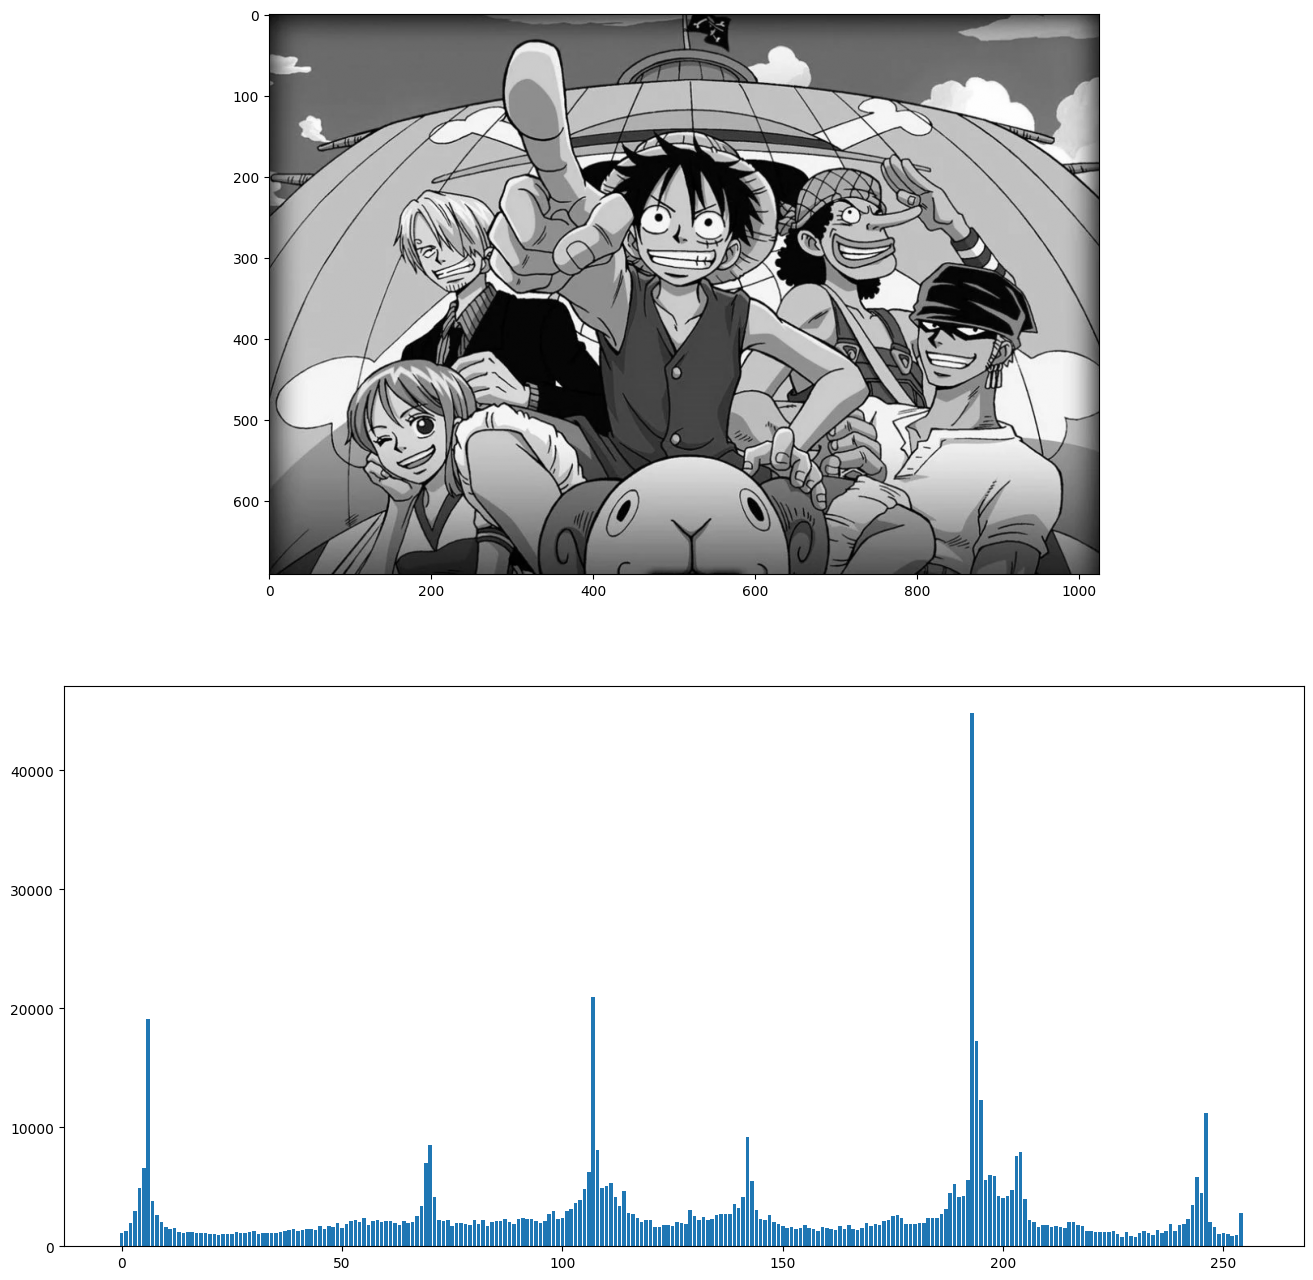

In [32]:
onePiece = np.array(Image.open('OnePiece.png'))
pesos = np.array([0.2126, 0.7152, 0.0722])
onepiece_gray = (onePiece[..., :3] * pesos).sum(axis=2).astype(np.uint8)
show_histogram_gray(onepiece_gray)

# Obter as dimensões (usando o fatiamento que aprendemos)
l, c = onepiece_gray.shape[:2]

# Calcular o Histograma e a Função de Distribuição Acumulada (FDC/CDF)
hist = histogram_gray(onepiece_gray)
fdc = hist.cumsum() # Soma acumulada dos pixels

# Aplicamos a fórmula em todos os 256 níveis de uma vez
fdc_min = fdc.min()
numerador = (fdc - fdc_min) * 255
denominador = (l * c) - fdc_min

if denominador == 0:
    tabela_mapeamento = np.zeros(256, dtype=np.uint8)
else:
    tabela_mapeamento = np.round(numerador / denominador).astype(np.uint8)

# 4. Aplicar o mapeamento na imagem original para equalizar
onepiece_equalizada = tabela_mapeamento[onepiece_gray]

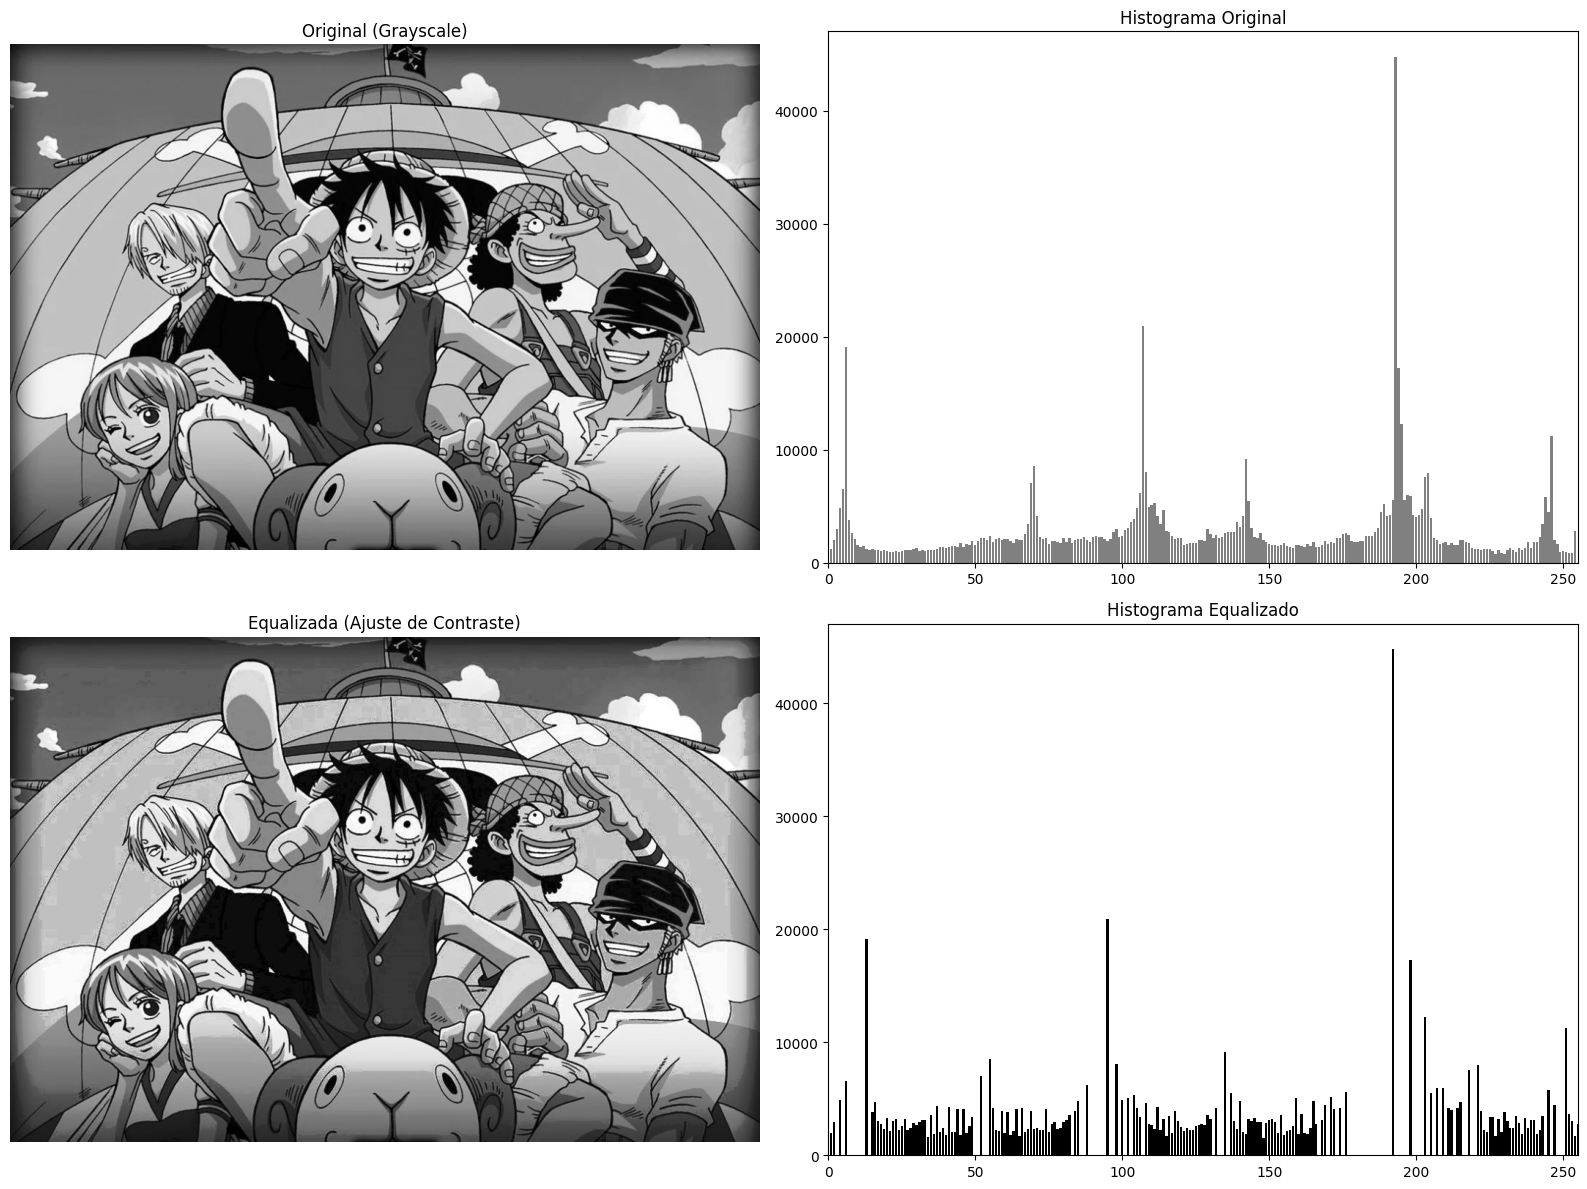

In [33]:
# Criando a visualização comparativa
plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
plt.title("Original (Grayscale)")
plt.imshow(onepiece_gray, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("Histograma Original")
plt.bar(range(256), hist, color='gray')
plt.xlim([0, 255])

plt.subplot(2, 2, 3)
plt.title("Equalizada (Ajuste de Contraste)")
plt.imshow(onepiece_equalizada, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

hist_equalizado = histogram_gray(onepiece_equalizada)

plt.subplot(2, 2, 4)
plt.title("Histograma Equalizado")
plt.bar(range(256), hist_equalizado, color='black')
plt.xlim([0, 255])

plt.tight_layout()
plt.show()